# Section 2 — ETL 

In [2]:
!ls /kaggle/input/notebooks/mirakh/01-load-validate-ipynb/

class_distribution.png	df_raw.csv	    __output__.json    __results__.html
custom.css		__notebook__.ipynb  __results___files


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings, gc
warnings.filterwarnings('ignore')

In [4]:
OUTPUT_PATH = '/kaggle/working/'

# ── E : Extract — Load df_raw from Section 1

In [5]:
df = pd.read_csv('/kaggle/input/notebooks/mirakh/01-load-validate-ipynb/df_raw.csv', low_memory=False)
df.columns = df.columns.str.strip()

print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded : 2,830,743 rows × 80 columns


# ── T : Transform — Preprocessing

── T1 : Preprocessing — Step 1 : Remove useless columns
source_file       → traceability column we added, useless for ML
Fwd Header Length.1 → exact duplicate of Fwd Header Length

In [6]:
cols_to_drop = ['source_file', 'Fwd Header Length.1']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df.drop(columns=cols_to_drop, inplace=True)

print(f' Columns removed : {cols_to_drop}')
print(f' Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

 Columns removed : ['source_file', 'Fwd Header Length.1']
 Shape : 2,830,743 rows × 78 columns


── T1 : Preprocessing — Step 2 : Remove duplicate rows
256,479 duplicate rows detected in Section 1
Keeping duplicates = model learns same examples multiple times = overfitting

In [7]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = df.shape[0]

print(f'Duplicates removed : {before - after:,}')
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicates removed : 308,381
Shape : 2,522,362 rows × 78 columns


── T1 : Preprocessing — Step 3 : Fix infinite and missing values
Flow Bytes/s and Flow Packets/s contain inf (division by zero)
inf → NaN → replaced by median

In [8]:
# Step 1 : inf → NaN
inf_before = np.isinf(df.select_dtypes(include='number')).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Infinite values replaced : {inf_before:,}')

Infinite values replaced : 2,775


In [9]:
# Step 2 : NaN → median
nan_before = df.isnull().sum().sum()
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f' {col} → filled with median ({median_val:.4f})')

 Flow Bytes/s → filled with median (3715.0379)
 Flow Packets/s → filled with median (69.7422)


In [10]:
print(f'Missing values fixed : {nan_before:,} → {df.isnull().sum().sum()}')

Missing values fixed : 3,128 → 0


── T1 : Preprocessing — Step 4 : Remove constant columns
A constant column has only 1 unique value across all rows
It gives ZERO information to the ML model

In [11]:
constant_cols = [col for col in df.columns
                 if df[col].nunique() <= 1 and col != 'Label']

print(f'Constant columns found : {len(constant_cols)}')
for c in constant_cols:
    print(f'   → {c} = {df[c].unique()}')

df.drop(columns=constant_cols, inplace=True)

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Constant columns found : 8
   → Bwd PSH Flags = [0]
   → Bwd URG Flags = [0]
   → Fwd Avg Bytes/Bulk = [0]
   → Fwd Avg Packets/Bulk = [0]
   → Fwd Avg Bulk Rate = [0]
   → Bwd Avg Bytes/Bulk = [0]
   → Bwd Avg Packets/Bulk = [0]
   → Bwd Avg Bulk Rate = [0]
Shape : 2,522,362 rows × 70 columns


── T2 : Feature Engineering — Step 1 : Encode Label column
ML models only understand numbers, not text
BENIGN → 0
Any attack → 1  (binary classification)
Also create multiclass encoding for later use

In [12]:
# Binary encoding
df['Label_binary'] = (df['Label'] != 'BENIGN').astype(int)

In [13]:
# Multiclass encoding
le = LabelEncoder()
df['Label_multiclass'] = le.fit_transform(df['Label'])

In [14]:
# Show mapping
print('Label mapping :')
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for label, code in sorted(mapping.items(), key=lambda x: x[1]):
    count = (df['Label'] == label).sum()
    print(f'   {code:2d} = {label:<35} ({count:,} rows)')

print(f'Label_binary    : 0={(df["Label_binary"]==0).sum():,} | 1={(df["Label_binary"]==1).sum():,}')
print(f'Label_multiclass : {df["Label_multiclass"].nunique()} classes')

Label mapping :
    0 = BENIGN                              (2,096,484 rows)
    1 = Bot                                 (1,953 rows)
    2 = DDoS                                (128,016 rows)
    3 = DoS GoldenEye                       (10,286 rows)
    4 = DoS Hulk                            (172,849 rows)
    5 = DoS Slowhttptest                    (5,228 rows)
    6 = DoS slowloris                       (5,385 rows)
    7 = FTP-Patator                         (5,933 rows)
    8 = Heartbleed                          (11 rows)
    9 = Infiltration                        (36 rows)
   10 = PortScan                            (90,819 rows)
   11 = SSH-Patator                         (3,219 rows)
   12 = Web Attack � Brute Force            (1,470 rows)
   13 = Web Attack � Sql Injection          (21 rows)
   14 = Web Attack � XSS                    (652 rows)
Label_binary    : 0=2,096,484 | 1=425,878
Label_multiclass : 15 classes


 ── T2 : Feature Engineering — Step 2 : Normalize features
Problem : columns have very different scales
Flow Duration → 0 to 120,000,000
Destination Port → 0 to 65,535
ML model treats large numbers as more important → wrong !
Solution : StandardScaler → everything between -3 and +3

In [16]:
# Columns to exclude from normalization
exclude = ['Label', 'Label_binary', 'Label_multiclass']
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude]

print(f'Normalizing {len(feature_cols)} features...')

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f'Normalization done')
print(f'   → Mean after scaling  : {df[feature_cols].mean().mean():.6f} (≈ 0)')
print(f'   → Std after scaling   : {df[feature_cols].std().mean():.6f} (≈ 1)')

Normalizing 69 features...
Normalization done
   → Mean after scaling  : 0.000000 (≈ 0)
   → Std after scaling   : 1.000000 (≈ 1)


# Visualization Before vs After ETL# 

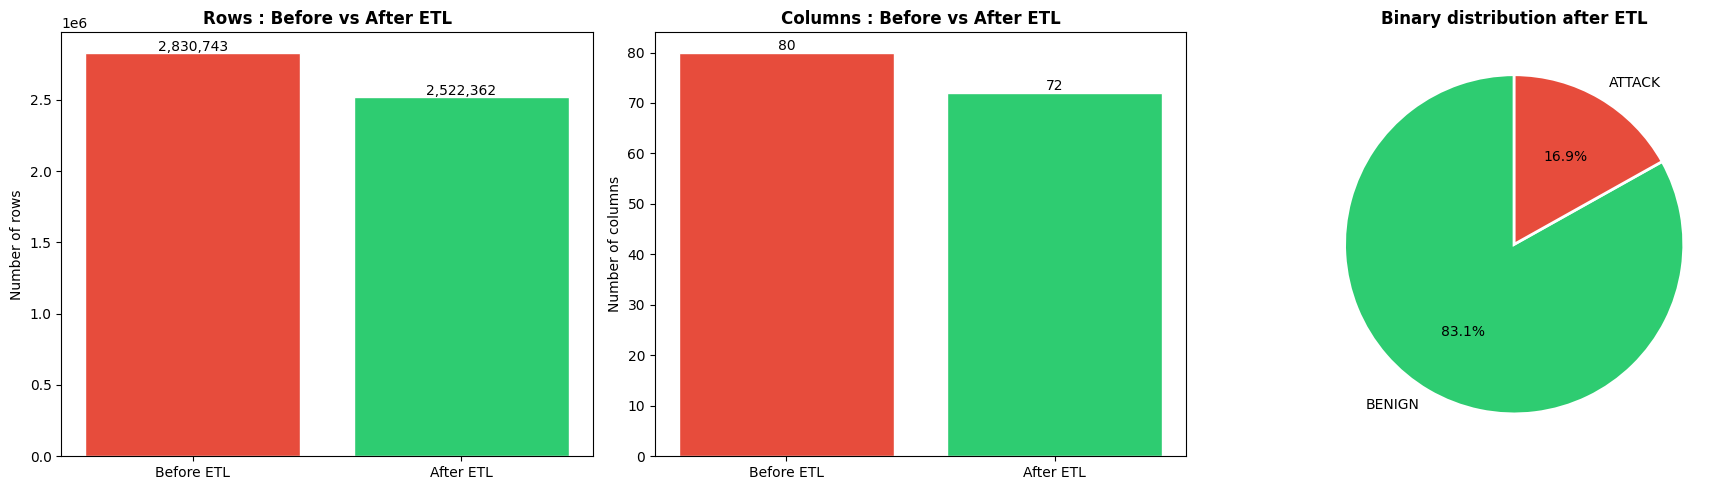

Graph saved : etl_comparison.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 : Rows before vs after
categories = ['Before ETL', 'After ETL']
values = [2830743, df.shape[0]]
axes[0].bar(categories, values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Rows : Before vs After ETL', fontweight='bold')
axes[0].set_ylabel('Number of rows')
for i, v in enumerate(values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontsize=10)

# Plot 2 : Columns before vs after
values2 = [80, df.shape[1]]
axes[1].bar(categories, values2, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Columns : Before vs After ETL', fontweight='bold')
axes[1].set_ylabel('Number of columns')
for i, v in enumerate(values2):
    axes[1].text(i, v + 0.5, f'{v}', ha='center', fontsize=10)

# Plot 3 : Class distribution after ETL
binary_counts = df['Label_binary'].value_counts()
binary_counts.index = ['BENIGN', 'ATTACK']
colors = ['#2ecc71', '#e74c3c']
binary_counts.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', colors=colors,
                   startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Binary distribution after ETL', fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'etl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved : etl_comparison.png')

# Visualization : Multiclass distribution# 

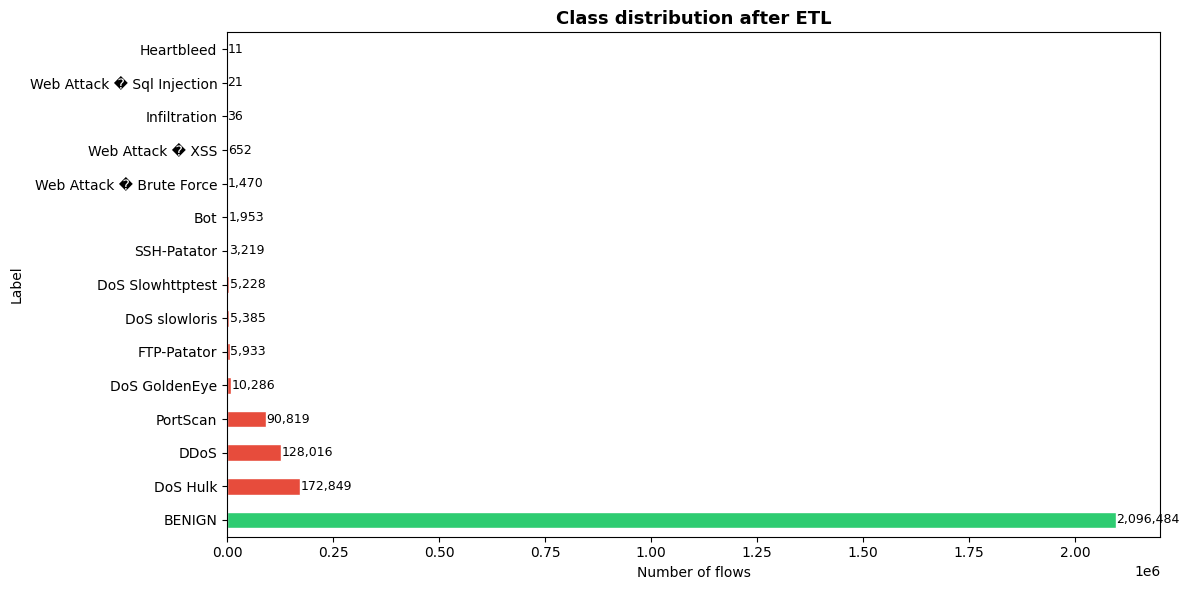

Graph saved : multiclass_distribution.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

multi_counts = df['Label'].value_counts()
colors = ['#2ecc71' if x == 'BENIGN' else '#e74c3c' for x in multi_counts.index]
multi_counts.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Class distribution after ETL', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of flows')

for i, v in enumerate(multi_counts):
    ax.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'multiclass_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved : multiclass_distribution.png')

# Final verification# 

In [19]:
print('=' * 55)
print('   FINAL VERIFICATION AFTER ETL')
print('=' * 55)
print(f'\nFinal shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Infinite values : {np.isinf(df.select_dtypes(include="number")).sum().sum()}')
print(f'Missing values  : {df.isnull().sum().sum()}')
print(f'Duplicates      : {df.duplicated().sum()}')
print(f'Constant cols   : {sum(df[c].nunique() <= 1 for c in df.columns)}')

print(f'\nBefore ETL vs After ETL :')
print(f'   Rows    : 2,830,743  ->  {df.shape[0]:,}')
print(f'   Columns : 80         ->  {df.shape[1]}')

print(f'\nLabel_binary distribution :')
print(f'   BENIGN (0) : {(df["Label_binary"]==0).sum():,}')
print(f'   ATTACK (1) : {(df["Label_binary"]==1).sum():,}')
ratio = (df["Label_binary"]==0).sum() / (df["Label_binary"]==1).sum()
print(f'   Ratio       : {ratio:.1f}x')
print('=' * 55)

   FINAL VERIFICATION AFTER ETL

Final shape     : 2,522,362 rows x 72 columns
Infinite values : 0
Missing values  : 0
Duplicates      : 6
Constant cols   : 0

Before ETL vs After ETL :
   Rows    : 2,830,743  ->  2,522,362
   Columns : 80         ->  72

Label_binary distribution :
   BENIGN (0) : 2,096,484
   ATTACK (1) : 425,878
   Ratio       : 4.9x


# — L : Load — Save df_clean.csv

In [ ]:
save_path = OUTPUT_PATH + 'df_clean.csv'
df.to_csv(save_path, index=False)

gc.collect()

print(f'Clean dataset saved : {save_path}')
print(f'   -> {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nSection 2 completed -----> Section 3 : ML Modeling')